In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd


In [12]:
#data loading
df = pd.read_csv(r'C:\temp_programming_remove_able\maze_solve_optimization\total_simulation_results.csv')
df = df.sort_values('Spawn_Strategy')
df.shape

(1718334, 12)

In [13]:
# 성공 여부만 탐색
df = df[df["Success"]==True]

C:\Users\user\AppData\Local\Temp\ipykernel_17336\3205040075.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spawn_Strategy', y='Used_Tick', palette='Blues')


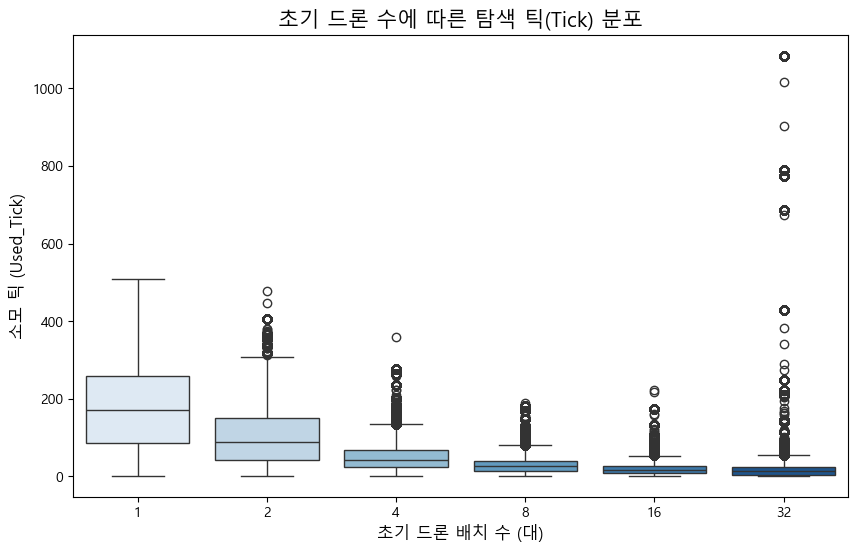

[1단계 ANOVA 검정] P-value: 0.00000

결론: 초기 드론 배치 수에 따라 탐색 성능에 유의미한 차이가 존재합니다.

[2단계 Tukey HSD 사후 검정 표]
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1 group2  meandiff p-adj   lower     upper   reject
--------------------------------------------------------
     1      2   -74.349   0.0  -74.8276  -73.8704   True
     1      4 -126.2931   0.0 -126.7717 -125.8145   True
     1      8 -149.2154   0.0  -149.694 -148.7368   True
     1     16 -159.7761   0.0 -160.2547 -159.2975   True
     1     32 -159.4788   0.0 -159.9574 -159.0002   True
     2      4  -51.9441   0.0  -52.4227  -51.4655   True
     2      8  -74.8664   0.0  -75.3451  -74.3878   True
     2     16  -85.4271   0.0  -85.9057  -84.9485   True
     2     32  -85.1298   0.0  -85.6084  -84.6512   True
     4      8  -22.9223   0.0  -23.4009  -22.4437   True
     4     16   -33.483   0.0  -33.9616  -33.0044   True
     4     32  -33.1857   0.0  -33.6643  -32.7071   True
     8     16  -10.5607   0.0  -11.0393  -10.

In [14]:
#box plot
plt.figure(figsize=(10, 6))
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sns.boxplot(data=df, x='Spawn_Strategy', y='Used_Tick', palette='Blues')
plt.title('초기 드론 수에 따른 탐색 틱(Tick) 분포', fontsize=15)
plt.xlabel('초기 드론 배치 수 (대)', fontsize=12)
plt.ylabel('소모 틱 (Used_Tick)', fontsize=12)
plt.show()

# ---------------------------------------------------------
# 3. 분산 분석 (ANOVA) 및 사후 검정
# ---------------------------------------------------------
groups = [group['Used_Tick'].values for name, group in df.groupby('Spawn_Strategy')]
f_stat, p_value = stats.f_oneway(*groups)

print(f"[1단계 ANOVA 검정] P-value: {p_value:.5f}\n")

if p_value < 0.05:
    print("결론: 초기 드론 배치 수에 따라 탐색 성능에 유의미한 차이가 존재합니다.\n")
    print("="*50)
    print("[2단계 Tukey HSD 사후 검정 표]")
    print("="*50)
    
    # 튜키 검정 실행
    tukey_result = pairwise_tukeyhsd(endog=df['Used_Tick'], 
                                     groups=df['Spawn_Strategy'], 
                                     alpha=0.05)
    print(tukey_result)
else:
    print("결론: 통계적으로 유의미한 성능 차이가 발견되지 않았습니다.")